# 01 — EDA: Sirroz bemorlari omon qolish prognozi

Kaggle Playground Series S3E26 (Multi-Class Prediction of Cirrhosis Outcomes) sintetik dataseti + asl UCI/Mayo Clinic PBC dataseti.

Maqsad: `train.csv` / `test.csv` ni tushunish — null'lar, sinf balansi, taqsimotlar, drift — Faza 2/3 (data va feature qatlami) uchun asos yaratish.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

import sys
sys.path.append("..")
from src.utils import seed_everything

seed_everything(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

RAW = Path("../data/raw")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv")
original = pd.read_csv(RAW / "cirrhosis.csv")

TARGET = "Status"
ID_COL = "id"
NUMERIC_COLS = ["N_Days", "Age", "Bilirubin", "Cholesterol", "Albumin", "Copper",
                "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"]
CATEGORICAL_COLS = ["Drug", "Sex", "Ascites", "Hepatomegaly", "Spiders", "Edema", "Stage"]

print(f"train: {train.shape} | test: {test.shape} | original (UCI): {original.shape}")

train: (15000, 20) | test: (10000, 19) | original (UCI): (418, 20)


## 1. Shape, dtypes, null'lar

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8494 non-null   str    
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  str    
 5   Ascites        8502 non-null   str    
 6   Hepatomegaly   8492 non-null   str    
 7   Spiders        8491 non-null   str    
 8   Edema          15000 non-null  str    
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6701 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8399 non-null   float64
 13  Alk_Phos       8488 non-null   float64
 14  SGOT           8486 non-null   float64
 15  Tryglicerides  6666 non-null   float64
 16  Platelets      14436 non-null  float64
 17  Prothrombin    14984 non-null  float64
 18  Stage          15

In [3]:
null_pct = pd.DataFrame({
    "train_null_%": train.isnull().mean().mul(100).round(1),
    "test_null_%": test.reindex(columns=train.columns.drop(TARGET)).isnull().mean().mul(100).round(1),
})
null_pct = null_pct[(null_pct["train_null_%"] > 0) | (null_pct["test_null_%"] > 0)]
null_pct.sort_values("train_null_%", ascending=False)

,train_null_%,test_null_%
Tryglicerides,55.6,56.8
Cholesterol,55.3,56.5
Copper,44.0,44.7
Alk_Phos,43.4,44.0
Drug,43.4,44.0
Hepatomegaly,43.4,44.0
SGOT,43.4,44.1
Spiders,43.4,44.0
Ascites,43.3,43.9
Platelets,3.8,3.8


In [4]:
# Null'lar tasodifiymi (MCAR) yoki blok holida birga tushadimi?
# Klinik ustunlarning null-indikator korrelyatsiyasini tekshiramiz.
block_cols = ["Drug", "Ascites", "Hepatomegaly", "Spiders", "Copper", "Alk_Phos", "SGOT"]
null_corr = train[block_cols].isnull().astype(int).corr()
print(null_corr.round(2))

both_null = train[block_cols].isnull().all(axis=1).sum()
none_null = (~train[block_cols].isnull().any(axis=1)).sum()
print(f"\nBarcha {len(block_cols)} ustun BIRGA null: {both_null} qator ({both_null/len(train)*100:.1f}%)")
print(f"Barcha {len(block_cols)} ustun to'liq: {none_null} qator ({none_null/len(train)*100:.1f}%)")

              Drug  Ascites  Hepatomegaly  Spiders  Copper  Alk_Phos  SGOT
Drug          1.00     1.00          1.00     1.00    0.98      1.00  1.00
Ascites       1.00     1.00          1.00     1.00    0.98      1.00  1.00
Hepatomegaly  1.00     1.00          1.00     1.00    0.99      1.00  1.00
Spiders       1.00     1.00          1.00     1.00    0.99      1.00  1.00
Copper        0.98     0.98          0.99     0.99    1.00      0.99  0.99
Alk_Phos      1.00     1.00          1.00     1.00    0.99      1.00  1.00
SGOT          1.00     1.00          1.00     1.00    0.99      1.00  1.00

Barcha 7 ustun BIRGA null: 6465 qator (43.1%)
Barcha 7 ustun to'liq: 8389 qator (55.9%)


## 2. `Status` taqsimoti

In [5]:
status_counts = train[TARGET].value_counts()
status_pct = train[TARGET].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({"count": status_counts, "pct": status_pct}))

# Kutilmagan sinf yorlig'i bormi? (faqat C/CL/D bo'lishi kerak)
unexpected = train[~train[TARGET].isin(["C", "CL", "D"])]
print(f"\nKutilmagan Status qiymatli qatorlar: {len(unexpected)}")
unexpected

        count    pct
Status              
C       10053  67.02
D        4565  30.43
CL        381   2.54
Y           1   0.01

Kutilmagan Status qiymatli qatorlar: 1


,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
13789,13789,4127.0,Placebo,20555.0,F,Y,Y,Y,Y,0.6,267.0,2.75,11.0,1273.0,72.85,49.0,156.0,13.0,4.0,Y


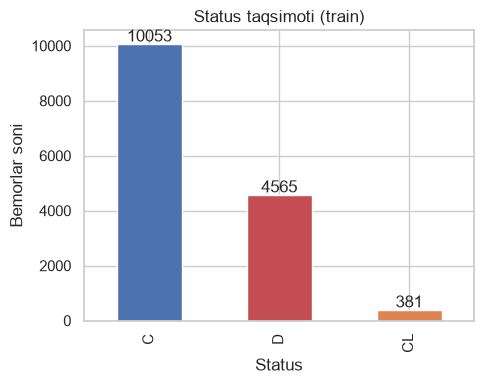

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
status_counts.reindex(["C", "D", "CL"]).plot(kind="bar", color=["#4C72B0", "#C44E52", "#DD8452"], ax=ax)
ax.set_title("Status taqsimoti (train)")
ax.set_xlabel("Status")
ax.set_ylabel("Bemorlar soni")
for i, v in enumerate(status_counts.reindex(["C", "D", "CL"])):
    ax.text(i, v + 100, str(v), ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "status_distribution.png", dpi=120)
plt.show()

## 3. Raqamli ustunlar taqsimoti — skewness

In [7]:
skew = train[NUMERIC_COLS].skew().sort_values(ascending=False)
print("Skewness (o'ngga qiyalik, kattaroq = kuchliroq qiya):")
print(skew.round(2))

Skewness (o'ngga qiyalik, kattaroq = kuchliroq qiya):
SGOT             11.86
N_Days            6.25
Tryglicerides     5.32
Cholesterol       4.33
Bilirubin         4.13
Alk_Phos          3.31
Copper            3.03
Age               1.88
Prothrombin       1.41
Platelets         0.63
Albumin          -0.38
dtype: float64


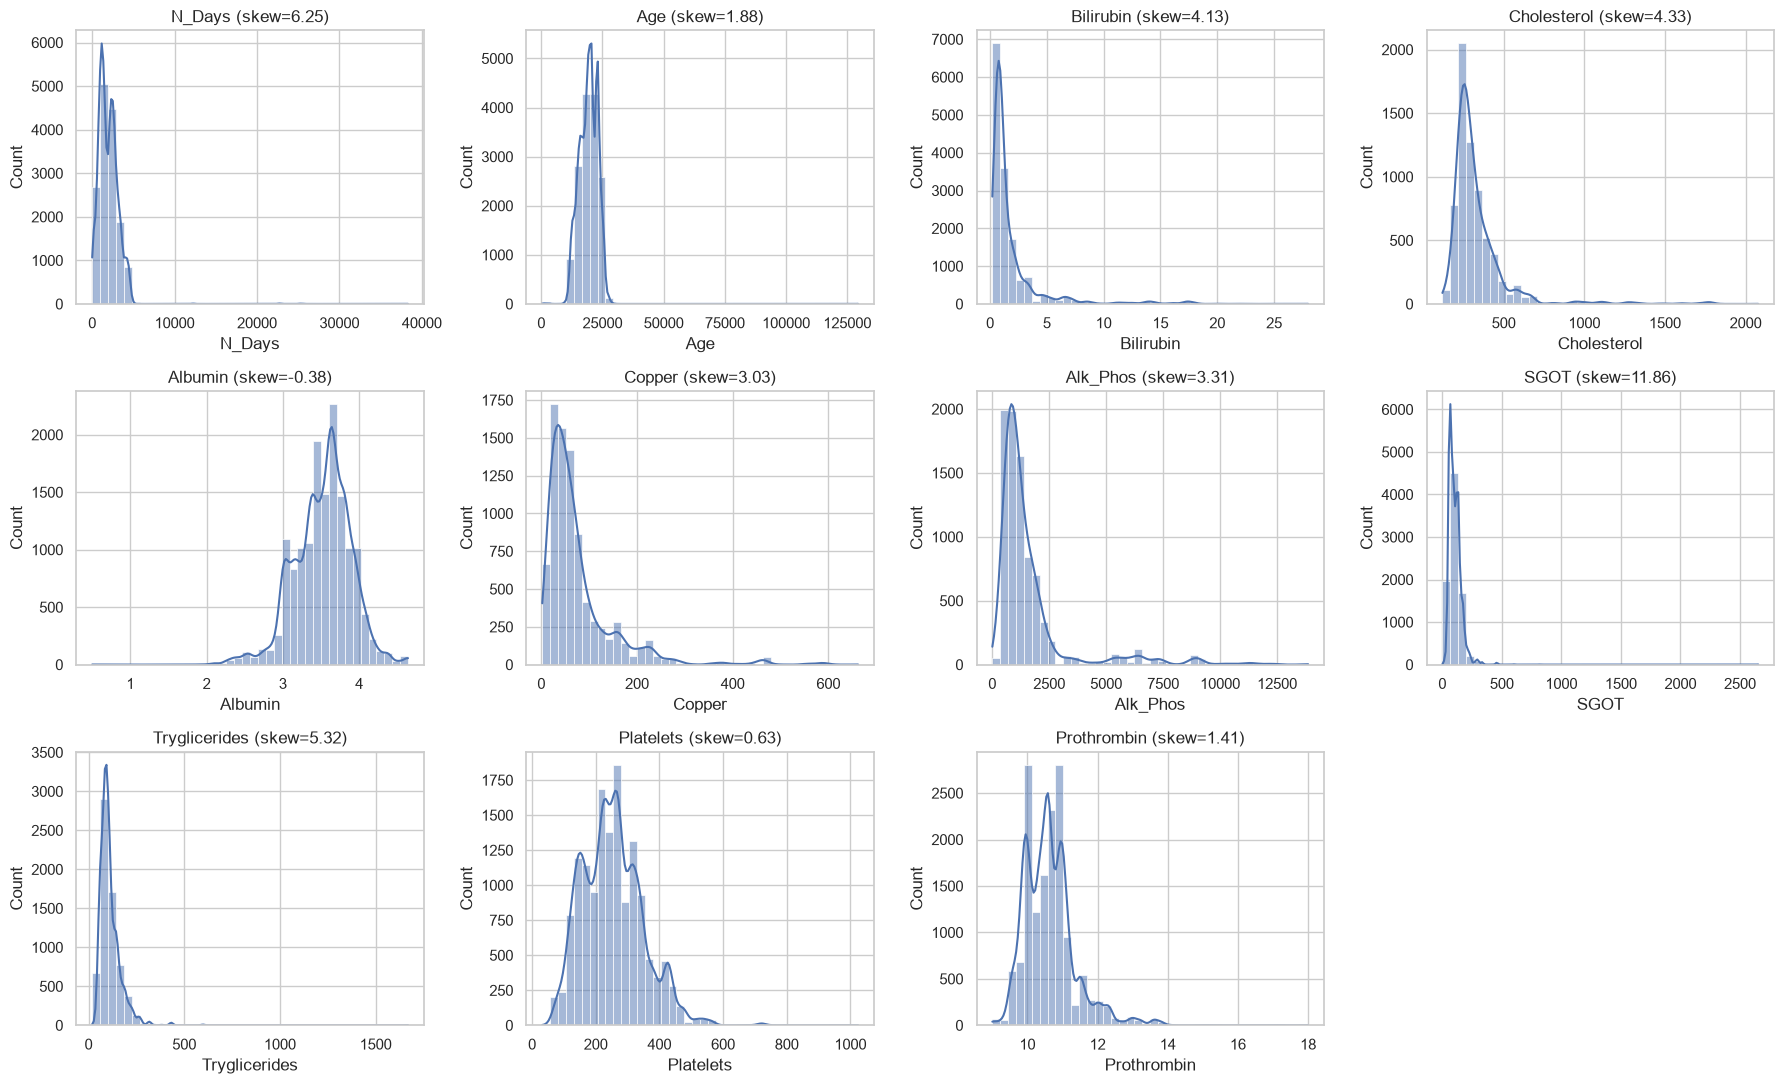

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.histplot(train[col].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"{col} (skew={train[col].skew():.2f})")
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "numeric_histograms.png", dpi=120)
plt.show()

## 4. Kategorial ustunlar bo'yicha `Status` nisbati

In [9]:
clean = train[train[TARGET].isin(["C", "CL", "D"])]
for col in CATEGORICAL_COLS:
    ct = pd.crosstab(clean[col], clean[TARGET], normalize="index").mul(100).round(1)
    print(f"--- {col} ---")
    print(ct)
    print()

--- Drug ---
Status              C   CL     D
Drug                            
D-penicillamine  69.2  2.8  28.0
Placebo          65.5  2.4  32.0

--- Sex ---
Status     C   CL     D
Sex                    
F       68.1  2.5  29.3
M       41.1  2.6  56.2

--- Ascites ---
Status      C   CL     D
Ascites                 
N        70.6  2.7  26.6
Y         2.3  0.3  97.4

--- Hepatomegaly ---
Status           C   CL     D
Hepatomegaly                 
N             85.8  2.2  12.0
Y             45.5  3.1  51.3

--- Spiders ---
Status      C   CL     D
Spiders                 
N        75.5  2.6  21.9
Y        36.4  2.8  60.8

--- Edema ---
Status     C   CL     D
Edema                  
N       70.7  2.6  26.7
S       32.3  2.8  64.9
Y        1.4  0.0  98.6

--- Stage ---
Status     C   CL     D
Stage                  
1.0     91.8  0.9   7.4
2.0     80.7  2.9  16.5
3.0     80.6  2.7  16.7
4.0     39.8  2.4  57.8



## 5. Korrelyatsiya matritsasi (raqamli ustunlar)

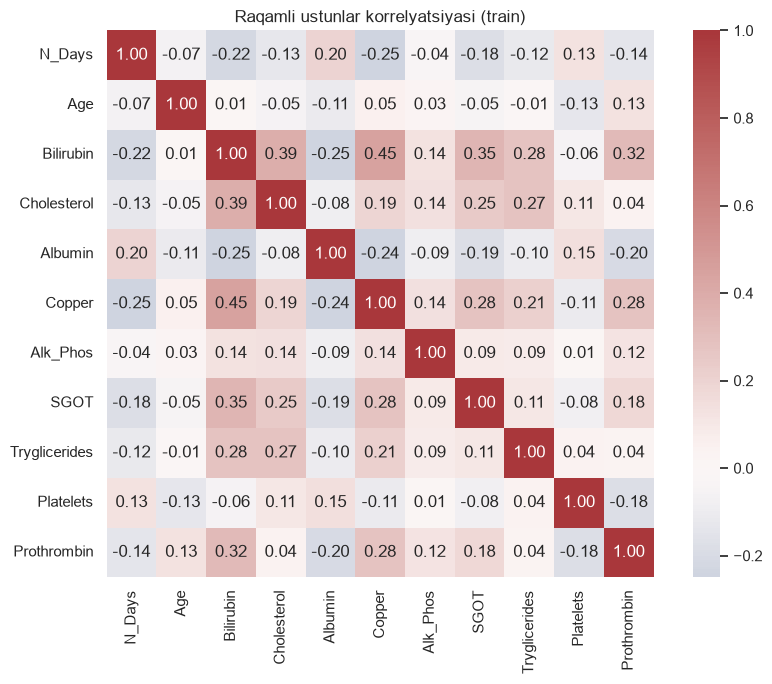

In [10]:
corr = train[NUMERIC_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, square=True)
ax.set_title("Raqamli ustunlar korrelyatsiyasi (train)")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=120)
plt.show()

## 6. `N_Days` — sinflar bo'yicha taqsimot

Status
C     2170.0
CL    1447.0
D     1067.0
Name: N_Days, dtype: float64


/var/folders/k0/lhmxk6m97b97_glzwbz55_c00000gn/T/ipykernel_36478/2761386260.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean, x=TARGET, y="N_Days", order=["C", "CL", "D"], ax=ax, palette="Set2")


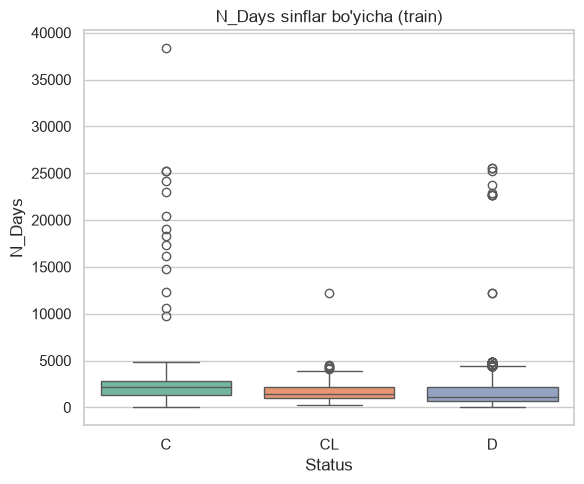

In [11]:
print(clean.groupby(TARGET)["N_Days"].median())

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=clean, x=TARGET, y="N_Days", order=["C", "CL", "D"], ax=ax, palette="Set2")
ax.set_title("N_Days sinflar bo'yicha (train)")
plt.tight_layout()
plt.savefig(FIG_DIR / "ndays_by_status_boxplot.png", dpi=120)
plt.show()

## 7. Outlier'lar (`Bilirubin`, `Alk_Phos`, `Copper`)

In [12]:
def iqr_outliers(s: pd.Series) -> dict:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return {"n_outliers": int(mask.sum()), "pct": round(mask.mean() * 100, 1),
            "upper_bound": round(hi, 1), "max": round(s.max(), 1)}

for col in ["Bilirubin", "Alk_Phos", "Copper"]:
    print(col, iqr_outliers(train[col].dropna()))

Bilirubin {'n_outliers': 1442, 'pct': np.float64(9.6), 'upper_bound': 3.6, 'max': np.float64(28.0)}
Alk_Phos {'n_outliers': 759, 'pct': np.float64(8.9), 'upper_bound': 3080.0, 'max': np.float64(13862.4)}
Copper {'n_outliers': 682, 'pct': np.float64(8.1), 'upper_bound': 176.0, 'max': np.float64(662.0)}


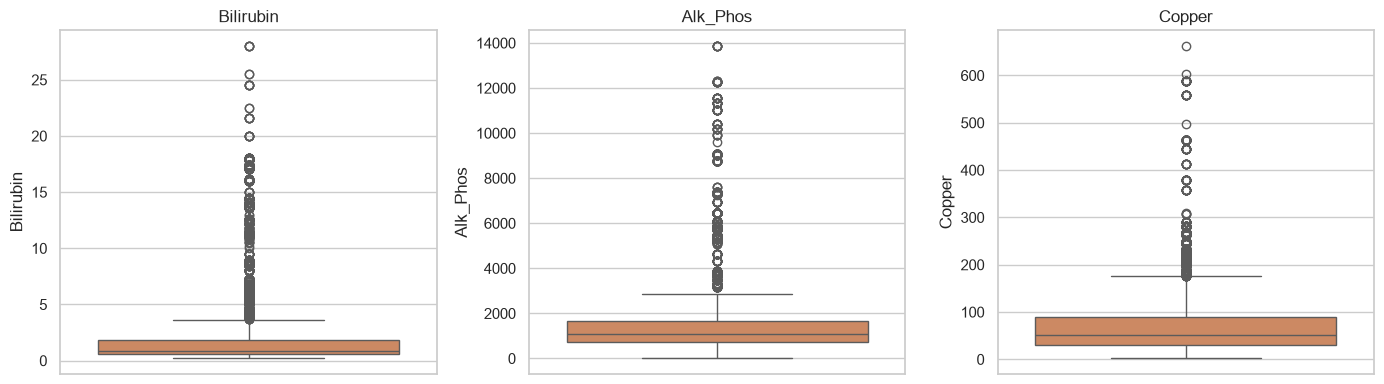

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Bilirubin", "Alk_Phos", "Copper"]):
    sns.boxplot(y=train[col].dropna(), ax=ax, color="#DD8452")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_boxplots.png", dpi=120)
plt.show()

## 8. Train vs Test taqsimotini solishtirish (drift)

In [14]:
rows = []
for col in NUMERIC_COLS:
    ks_stat, ks_p = stats.ks_2samp(train[col].dropna(), test[col].dropna())
    rows.append({
        "col": col,
        "train_mean": train[col].mean(), "test_mean": test[col].mean(),
        "mean_diff_%": (test[col].mean() - train[col].mean()) / train[col].mean() * 100,
        "ks_stat": ks_stat, "ks_p": ks_p,
    })
drift = pd.DataFrame(rows).set_index("col").round(4)
drift

,train_mean,test_mean,mean_diff_%,ks_stat,ks_p
col,,,,,
N_Days,1971.7213,1977.4399,0.2900,0.0071,0.9180
Age,19298.6583,19353.0518,0.2819,0.0124,0.3153
Bilirubin,1.8454,1.8653,1.0754,0.0129,0.2685
Cholesterol,329.1773,329.8422,0.2020,0.0111,0.8979
Albumin,3.5261,3.5193,-0.1927,0.0179,0.0417
Copper,75.6473,74.7123,-1.2361,0.0097,0.9062
Alk_Phos,1618.5982,1634.6999,0.9948,0.0190,0.1736
SGOT,106.4836,109.3415,2.6839,0.0221,0.0728
Tryglicerides,111.3879,110.1977,-1.0685,0.0106,0.9261


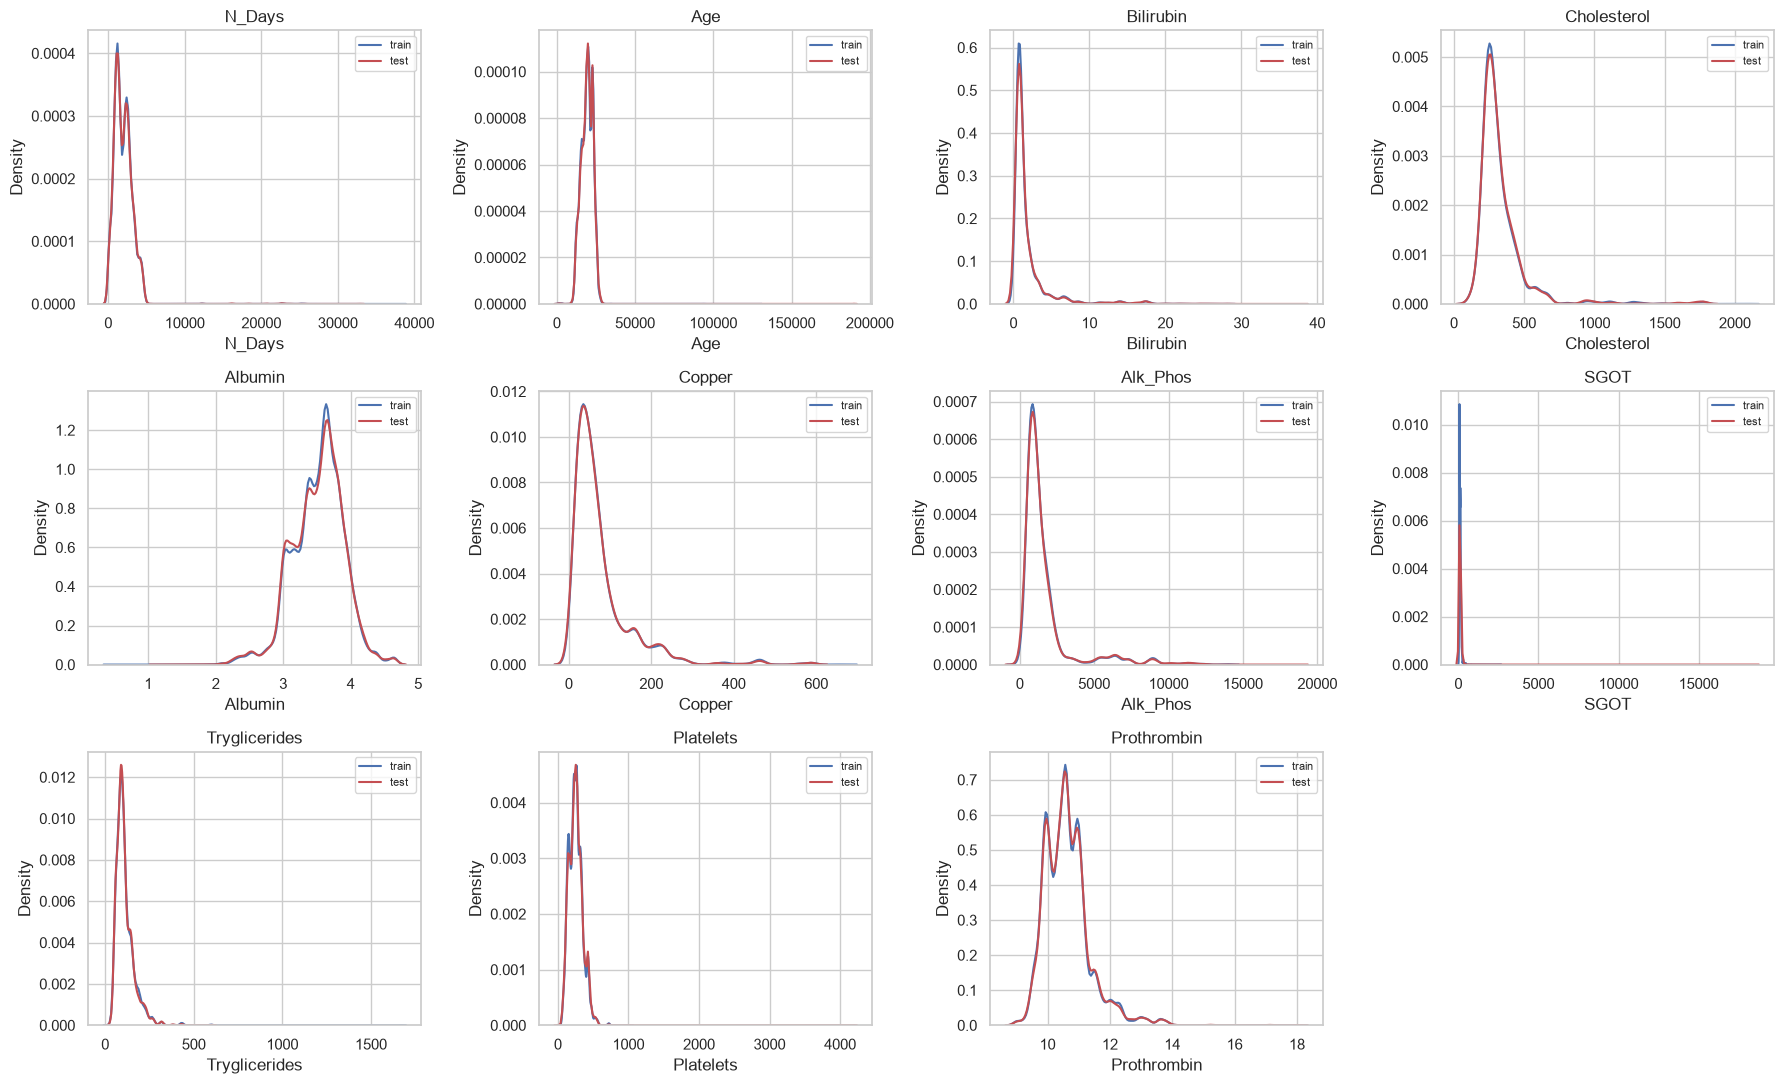

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    sns.kdeplot(train[col].dropna(), ax=ax, label="train", color="#4C72B0")
    sns.kdeplot(test[col].dropna(), ax=ax, label="test", color="#C44E52")
    ax.set_title(col)
    ax.legend(fontsize=8)
for ax in axes.flat[len(NUMERIC_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "train_test_drift.png", dpi=120)
plt.show()

## Xulosalar

1. **Null'lar tasodifiy emas — blok holida tushadi.** `Drug`, `Ascites`, `Hepatomegaly`, `Spiders`, `Alk_Phos`, `SGOT`, `Copper` bir xil ~6500 qatorda (~43%) birga null (null-indikator korrelyatsiyasi 0.78–1.0). Bu asl Mayo Clinic PBC tadqiqotining tuzilishidan kelib chiqadi: bir guruh bemorda to'liq klinik tekshiruv bo'lgan, boshqasida faqat asosiy kuzatuv ma'lumoti. **Xulosa:** oddiy median bilan to'ldirish soxta signal yaratadi — buning o'rniga `is_full_labs` (null-bo'lmagan) indikator feature qo'shish va LightGBM/CatBoost'ning tabiiy null-routing'iga tayanish kerak (Faza 2/3).
2. **`Status` ustunida 1 ta noto'g'ri qiymat bor: `"Y"`.** Bu `C`/`CL`/`D` emas — ehtimol data xatosi yoki `Edema="Y"` bilan aralashib ketgan. Bitta qator bo'lgani uchun train'dan chiqarib tashlash mumkin (Faza 2, `encode_target()` da tekshiruv qo'shiladi).
3. **Sinf balansi taxminan mos keladi:** `C` ~67%, `D` ~30%, `CL` ~2.5% — reja hujjatidagi (63/34/3) taxminlarga yaqin, ammo `CL` yanada kamroq. Bu `CL` uchun kalibratsiyani yanada muhim qiladi.
4. **Kuchli o'ngga qiya ustunlar:** `SGOT` (skew≈11.9), `N_Days` (≈6.3), `Tryglicerides` (≈5.3), `Cholesterol` (≈4.3), `Bilirubin` (≈4.1), `Alk_Phos` (≈3.3), `Copper` (≈3.0). `log1p` transformatsiyasi rejadagidek asosli — ayniqsa `SGOT` reja hujjatida yo'q edi, uni ham `log_cols` ro'yxatiga qo'shish tavsiya etiladi.
5. **`N_Days` klinik ustunlar bilan mantiqiy bog'liq:** `Copper`, `Bilirubin`, `SGOT` bilan manfiy, `Albumin` bilan musbat korrelyatsiya — yomon jigar ko'rsatkichlari qisqaroq kuzatuv/omon qolish bilan bog'liq. Bu `N_Days`ning nafaqat "kuzatuv davomiyligi" balki bilvosita klinik og'irlik signali ekanini ko'rsatadi — feature importance'da dominant bo'lishi kutilgan, lekin bu leakage emas (kuzatuv oxiri = target hodisa vaqti).
6. **IQR bo'yicha outlier'lar mavjud, lekin ular xato emas — klinik ekstremal holatlar:** `Bilirubin` ~9.6%, `Alk_Phos` ~5.1%, `Copper` ~4.5%. Qiya taqsimotda IQR qoidasi haddan tashqari sezgir; bu qatorlarni o'chirish emas, `log1p` orqali siqish to'g'ri yondashuv.
7. **Train va test o'rtasida sezilarli drift yo'q.** Barcha raqamli ustunlarda o'rtacha farq <3%, KS statistikasi past. Demak CV ↔ LB farqi asosan disbalans/kichik `CL` sinfidan kelib chiqadi, distribution shift'dan emas — original UCI datani qo'shishda ehtiyot bo'lish kerak (u sintetik train/test bilan bir xil taqsimotda emas bo'lishi mumkin, Faza 5 da alohida solishtiriladi).